In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import yaml
import hashlib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.xgb_train import train_xgboost
from src.models.lgbm_train import train_lightgbm
from src.models.catboost_train import train_catboost
from src.models.ensemble import create_ensemble
# CHANGED: Use sklearn metrics directly to avoid custom wrapper issues
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df
from src.eval.metrics import select_policy_thresholds

paths = load_paths()
logger = setup_logger(level="INFO")


In [2]:
features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

# Try to load old splits if available, otherwise default to unknown
vnat_old_path = paths.data_processed / "vnat" / "features_trainable.parquet"
if vnat_old_path.exists():
    logger.info(f"Loading existing splits from {vnat_old_path}")
    vnat_old = pd.read_parquet(vnat_old_path)
    split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
    vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
else:
    logger.warning(f"Old features file not found: {vnat_old_path}. All splits set to 'unknown' (will be re-split).")
    vnat_feats["split"] = "unknown"

# Filter: if we have splits, keep known ones. If all unknown, keep all (we'll split later).
if (vnat_feats["split"] != "unknown").any():
    vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()

# Apply min packets filter
if "q_min_packets_ok" in vnat_feats.columns:
    vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old_path = paths.data_processed / "iscx" / "features.parquet"
if iscx_old_path.exists():
    logger.info(f"Loading existing splits from {iscx_old_path}")
    iscx_old = pd.read_parquet(iscx_old_path)
    split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
    iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
else:
    logger.warning(f"Old features file not found: {iscx_old_path}. All splits set to 'unknown'.")
    iscx_feats["split"] = "unknown"

if (iscx_feats["split"] != "unknown").any():
    iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()

if "q_min_packets_ok" in iscx_feats.columns:
    iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
df_all["split"] = df_all["split"].replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})

logger.info("Rebalancing VNAT splits for robust evaluation...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()

# Always re-split VNAT to ensure we have train/val/test even if old file was missing
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx].copy()
vnat_temp = vnat_df.iloc[temp_idx].copy()

gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx].copy()
vnat_test = vnat_temp.iloc[test_idx].copy()

vnat_train["split"] = "train"
vnat_val["split"] = "val"
vnat_test["split"] = "test"

vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test], ignore_index=True)
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)

vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
logger.info(f"Enforcing Voipbuster splits: {vb_train_cap} -> TRAIN, {vb_test_cap} -> TEST")
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Final splits after rebalancing:\n", df_all["split"].value_counts())

# --- STEP 2: Compute Dataset-Balanced Sample Weights ---
logger.info("Computing Dataset-Balanced Sample Weights...")
train_mask = df_all["split"] == "train"
df_train = df_all[train_mask]

# Count samples per dataset in TRAIN
counts = df_train["dataset"].value_counts()
n_vnat = counts.get("vnat", 0)
n_iscx = counts.get("iscx", 0)
n_total = len(df_train)

print(f"Train counts: VNAT={n_vnat}, ISCX={n_iscx}, Total={n_total}")

# Calculate weights: w = 1 / (n_dataset)
# Normalize so mean weight is 1.0
w_vnat = n_total / (2 * n_vnat) if n_vnat > 0 else 0
w_iscx = n_total / (2 * n_iscx) if n_iscx > 0 else 0

print(f"Weights: VNAT={w_vnat:.4f}, ISCX={w_iscx:.4f}")

# Assign weights to df_all (default 1.0 for non-train, though not used for training)
df_all["sample_weight"] = 1.0
df_all.loc[train_mask & (df_all["dataset"] == "vnat"), "sample_weight"] = w_vnat
df_all.loc[train_mask & (df_all["dataset"] == "iscx"), "sample_weight"] = w_iscx

# Verify
print("Mean weight in TRAIN:", df_all.loc[train_mask, "sample_weight"].mean())
# -------------------------------------------------------

# --- LABEL CONSISTENCY CHECK (Added by Expert Assistant) ---
print("\n" + "="*60)
print("LABEL CONSISTENCY CHECK")
print("="*60)
print("VNAT VPN label meaning check:")
print(vnat_flows[vnat_flows["capture_id"].str.startswith("vpn_")]
      .groupby("capture_id")["label"].mean().head(10))

print("\nISCX VPN label meaning check:")
print(iscx_flows[iscx_flows["capture_id"].str.startswith("vpn_")]
      .groupby("capture_id")["label"].mean().head(10))
print("="*60 + "\n")

# --- PRE-FLIGHT CHECKS (Added by Expert Assistant) ---
logger.info("Running Pre-flight Diagnostics...")

# 1. Check for Leakage Columns
temp_pipe = FeaturePipeline()
temp_pipe.fit(df_all[df_all["split"] == "train"])
feat_cols = temp_pipe.model_feature_names()
print(f"Detected {len(feat_cols)} features.")
print("First 30 features:", feat_cols[:30])
suspicious = [c for c in feat_cols if any(x in c.lower() for x in ['id', 'label', 'split', 'pcap', 'capture', 'time', 'date'])]
if suspicious:
    print(f"WARNING: Suspicious feature names found: {suspicious}")

# 2. Zero Variance Check
X_train_check = temp_pipe.transform(df_all[df_all["split"] == "train"])
X_train_vals = X_train_check[feat_cols]
variances = X_train_vals.var()
zero_var_cols = variances[variances == 0].index.tolist()
if zero_var_cols:
    print(f"WARNING: Found {len(zero_var_cols)} zero-variance features: {zero_var_cols}")

# 3. Random Label Test (Improved: 20 seeds, 200 trees, Test set, Explicit sklearn)
logger.info("Running Random Label Smoke Test (20 seeds, 200 trees, Test set)...")
print("skm.roc_auc_score module:", skm.roc_auc_score.__module__)

# Debug: Print label counts
df_train_check = df_all[df_all["split"] == "train"]
df_test_check = df_all[df_all["split"] == "test"]
print("TRAIN label counts:", np.bincount(df_train_check["label"].astype(int)))
print("TEST label counts:", np.bincount(df_test_check["label"].astype(int)))

aucs = []
for seed in range(20):
    df_noise = df_train_check.copy()
    # Permute labels to preserve class balance
    df_noise["label"] = np.random.default_rng(seed).permutation(df_noise["label"].values)

    # Use temp_pipe features
    X_noise = temp_pipe.transform(df_noise)
    y_noise = df_noise["label"]

    # Use more robust model settings
    model_noise = xgb.XGBClassifier(n_estimators=200, max_depth=3, eval_metric="logloss", random_state=seed, n_jobs=1)
    model_noise.fit(X_noise[feat_cols], y_noise)

    # Eval on real TEST set (more stable than Val)
    X_test_check = temp_pipe.transform(df_test_check)
    y_test_real = df_test_check["label"]

    preds = model_noise.predict_proba(X_test_check[feat_cols])[:, 1]
    score = skm.roc_auc_score(y_test_real, preds)
    aucs.append(score)

    # Debug check for first run
    if seed == 0:
        auc_inv = skm.roc_auc_score(y_test_real, 1 - preds)
        print(f"DEBUG (seed 0): AUC(p)={score:.4f}, AUC(1-p)={auc_inv:.4f}")

print(f"Random Label AUCs (Test): {aucs}")
print(f"Mean Random Label AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}")

# 4. Correct Capture Holdout Test (GroupKFold)
logger.info("Running Robust Capture Holdout Test (GroupKFold)...")

# Work ONLY inside TRAIN split (this is the point of holdout)
df_train_only = df_all[df_all["split"] == "train"].copy()

# Use GroupKFold to ensure captures are not split across folds
gkf = GroupKFold(n_splits=5)
holdout_aucs = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(df_train_only, groups=df_train_only["capture_id"])):
    df_tr = df_train_only.iloc[tr_idx].copy()
    df_te = df_train_only.iloc[te_idx].copy()

    # Ensure test has both classes; otherwise skip
    if df_te["label"].nunique() < 2:
        print(f"Fold {fold}: Skipped (only 1 class in test)")
        continue

    # Fit pipeline fresh on train fold only
    pipe_ho = FeaturePipeline().fit(df_tr)
    ho_feats = pipe_ho.model_feature_names()

    X_tr = pipe_ho.transform(df_tr)[ho_feats]
    X_te = pipe_ho.transform(df_te)[ho_feats]

    # Use sample weights if available
    w_tr = df_tr["sample_weight"] if "sample_weight" in df_tr.columns else None

    model_ho = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42 + fold
    )
    model_ho.fit(X_tr, df_tr["label"], sample_weight=w_tr)

    p = model_ho.predict_proba(X_te)[:, 1]
    auc = skm.roc_auc_score(df_te["label"], p)
    holdout_aucs.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

if holdout_aucs:
    print(f"GroupKFold AUC mean±std (over {len(holdout_aucs)} folds): {np.mean(holdout_aucs):.4f} +/- {np.std(holdout_aucs):.4f}")
else:
    print("WARNING: No valid holdout runs completed.")

# 5. Cross-Domain Smoke Test (VNAT Train -> ISCX Test Only)
logger.info("Running VNAT -> ISCX Smoke Test...")
vnat_train_only = df_all[(df_all["dataset"] == "vnat") & (df_all["split"] == "train")]
iscx_test_only = df_all[(df_all["dataset"] == "iscx") & (df_all["split"] == "test")]

if len(vnat_train_only) > 0 and len(iscx_test_only) > 0:
    pipe_cross = FeaturePipeline().fit(vnat_train_only)
    X_cross_train = pipe_cross.transform(vnat_train_only)
    X_cross_test = pipe_cross.transform(iscx_test_only)
    cross_feats = pipe_cross.model_feature_names()

    # DEBUG: Dump shapes and labels for comparison with notebook 16
    print("DEBUG Cross-Domain (NB10):")
    print("VNAT train shape:", X_cross_train[cross_feats].shape)
    print("ISCX test shape:", X_cross_test[cross_feats].shape)
    print("ISCX test label counts:", np.bincount(iscx_test_only["label"].astype(int)))

    # UNIFIED PARAMS: Matching NB16 exactly
    model_cross = xgb.XGBClassifier(
        n_estimators=30,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42
    )
    model_cross.fit(X_cross_train[cross_feats], vnat_train_only["label"])

    preds_cross = model_cross.predict_proba(X_cross_test[cross_feats])[:, 1]

    # Save for comparison
    np.save(paths.artifacts_dir / "debug_y_iscx_nb10.npy", iscx_test_only["label"].astype(int).to_numpy())
    np.save(paths.artifacts_dir / "debug_p_iscx_nb10.npy", preds_cross)

    auc_cross = skm.roc_auc_score(iscx_test_only["label"], preds_cross)
    auc_cross_inv = skm.roc_auc_score(iscx_test_only["label"], 1 - preds_cross)

    print(f"VNAT -> ISCX AUC: {auc_cross:.4f}")
    print(f"VNAT -> ISCX AUC(1-p): {auc_cross_inv:.4f}")

    if auc_cross_inv > 0.60:
        print("WARNING: Inverted AUC is high! Check for label mapping inconsistency between datasets.")
    elif auc_cross > 0.99:
        print("WARNING: Perfect AUC on Cross-Domain test suggests LEAKAGE.")
    elif auc_cross < 0.55 and auc_cross_inv < 0.55:
        print("WARNING: Both AUCs are near random. Severe domain shift or feature mismatch.")

# --- 6. ADVANCED ROBUSTNESS EVALUATION (Added by Expert Assistant) ---
print("\n" + "="*60)
print("ADVANCED ROBUSTNESS EVALUATION")
print("="*60)

# 6.1 Domain-Specific GroupKFold
for dataset_name in ["vnat", "iscx"]:
    print(f"\n--- {dataset_name.upper()} GroupKFold (Train Split Only) ---")
    df_ds = df_all[(df_all["dataset"] == dataset_name) & (df_all["split"] == "train")].copy()

    if df_ds.empty:
        print(f"No train data for {dataset_name}")
        continue

    gkf_ds = GroupKFold(n_splits=5)
    ds_aucs = []

    for fold, (tr_idx, te_idx) in enumerate(gkf_ds.split(df_ds, groups=df_ds["capture_id"])):
        df_tr = df_ds.iloc[tr_idx].copy()
        df_te = df_ds.iloc[te_idx].copy()

        if df_te["label"].nunique() < 2: continue

        pipe_ds = FeaturePipeline().fit(df_tr)
        feats_ds = pipe_ds.model_feature_names()

        model_ds = xgb.XGBClassifier(n_estimators=100, max_depth=3, eval_metric="auc", n_jobs=1, random_state=42)
        model_ds.fit(pipe_ds.transform(df_tr)[feats_ds], df_tr["label"])

        p = model_ds.predict_proba(pipe_ds.transform(df_te)[feats_ds])[:, 1]
        ds_aucs.append(skm.roc_auc_score(df_te["label"], p))

    if ds_aucs:
        print(f"{dataset_name.upper()} GroupKFold AUC: {np.mean(ds_aucs):.4f} +/- {np.std(ds_aucs):.4f}")

# 6.2 Bidirectional Cross-Domain Test (Full)
print("\n--- Bidirectional Cross-Domain Test (Full Dataset) ---")
# Train on ALL VNAT (train+val+test), Test on ALL ISCX (train+val+test)
# This is a "maximal data" test for domain generalization
vnat_full = df_all[df_all["dataset"] == "vnat"].copy()
iscx_full = df_all[df_all["dataset"] == "iscx"].copy()

if not vnat_full.empty and not iscx_full.empty:
    # VNAT -> ISCX
    pipe_v2i = FeaturePipeline().fit(vnat_full)
    feats_v2i = pipe_v2i.model_feature_names()

    model_v2i = xgb.XGBClassifier(n_estimators=200, max_depth=3, eval_metric="auc", n_jobs=4, random_state=42)
    model_v2i.fit(pipe_v2i.transform(vnat_full)[feats_v2i], vnat_full["label"])

    p_iscx = model_v2i.predict_proba(pipe_v2i.transform(iscx_full)[feats_v2i])[:, 1]
    auc_v2i = skm.roc_auc_score(iscx_full["label"], p_iscx)
    print(f"Train VNAT (All) -> Test ISCX (All): AUC = {auc_v2i:.4f}")

    # ISCX -> VNAT
    pipe_i2v = FeaturePipeline().fit(iscx_full)
    feats_i2v = pipe_i2v.model_feature_names()

    model_i2v = xgb.XGBClassifier(n_estimators=200, max_depth=3, eval_metric="auc", n_jobs=4, random_state=42)
    model_i2v.fit(pipe_i2v.transform(iscx_full)[feats_i2v], iscx_full["label"])

    p_vnat = model_i2v.predict_proba(pipe_i2v.transform(vnat_full)[feats_i2v])[:, 1]
    auc_i2v = skm.roc_auc_score(vnat_full["label"], p_vnat)
    print(f"Train ISCX (All) -> Test VNAT (All): AUC = {auc_i2v:.4f}")

# 6.3 Application Holdout (Leave-One-App-Out)
print("\n--- Application Holdout (Leave-One-App-Out) ---")

# 1. Map capture_id -> app
def make_capture_to_app_map(flows: pd.DataFrame) -> pd.Series:
    if "app" not in flows.columns:
        return pd.Series(dtype=str)
    def mode_or_unknown(x):
        x = x.dropna()
        if len(x) == 0: return "unknown"
        return x.value_counts().idxmax()
    return flows.groupby("capture_id")["app"].apply(mode_or_unknown)

cap2app_vnat = make_capture_to_app_map(vnat_flows)
cap2app_iscx = make_capture_to_app_map(iscx_flows)
cap2app = pd.concat([cap2app_vnat, cap2app_iscx])

# 2. Merge into df_all
df_all["app"] = df_all["capture_id"].map(cap2app).fillna("unknown")

# 3. Normalize app names
df_all["app"] = (
    df_all["app"].astype(str)
    .str.lower()
    .str.strip()
    .replace({
        "skype_video": "skype",
        "skype_audio": "skype",
        "facebook_audio": "facebook",
        "facebook_chat": "facebook",
        "aim_chat": "aim",
        "icq_chat": "icq",
        "gmail_chat": "gmail",
        "hangouts_chat": "hangouts",
    }, regex=True) # Use regex=True for partial matches if needed, or exact dict
)
# Refine normalization for specific known patterns if simple dict didn't catch them
df_all.loc[df_all["app"].str.contains("skype"), "app"] = "skype"
df_all.loc[df_all["app"].str.contains("facebook"), "app"] = "facebook"
df_all.loc[df_all["app"].str.contains("netflix"), "app"] = "netflix"
df_all.loc[df_all["app"].str.contains("youtube"), "app"] = "youtube"
df_all.loc[df_all["app"].str.contains("spotify"), "app"] = "spotify"
df_all.loc[df_all["app"].str.contains("vimeo"), "app"] = "vimeo"
df_all.loc[df_all["app"].str.contains("bittorrent"), "app"] = "bittorrent"

# 4. Run LOAO on TRAIN split
df_train_loao = df_all[df_all["split"] == "train"].copy()
apps = sorted([a for a in df_train_loao["app"].unique() if a != "unknown"])

MIN_N = 200
MIN_POS = 20

loao_results = []

print(f"Testing {len(apps)} apps: {apps}")

for holdout_app in apps:
    # Hold out ALL captures for this app
    train_df = df_train_loao[df_train_loao["app"] != holdout_app].copy()
    test_df  = df_train_loao[df_train_loao["app"] == holdout_app].copy()

    # Guardrails
    if len(test_df) < MIN_N:
        # print(f"Skipping {holdout_app}: n={len(test_df)} < {MIN_N}")
        continue

    n_pos = test_df["label"].sum()
    n_neg = (test_df["label"] == 0).sum()

    if n_pos < MIN_POS or n_neg < MIN_POS:
        # print(f"Skipping {holdout_app}: unbalanced (pos={n_pos}, neg={n_neg})")
        continue

    pipe_loao = FeaturePipeline().fit(train_df)
    feats_loao = pipe_loao.model_feature_names()

    X_tr = pipe_loao.transform(train_df)[feats_loao]
    y_tr = train_df["label"].astype(int)

    X_te = pipe_loao.transform(test_df)[feats_loao]
    y_te = test_df["label"].astype(int)

    # Use sample weights if available
    w_tr = train_df["sample_weight"] if "sample_weight" in train_df.columns else None

    model_loao = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        random_state=42,
        n_jobs=4,
    )
    model_loao.fit(X_tr, y_tr, sample_weight=w_tr)

    p = model_loao.predict_proba(X_te)[:, 1]
    auc = skm.roc_auc_score(y_te, p)
    ap  = skm.average_precision_score(y_te, p)

    loao_results.append({
        "app": holdout_app,
        "n_test": len(test_df),
        "pos_rate": float(y_te.mean()),
        "auc": float(auc),
        "ap": float(ap),
    })

if loao_results:
    res_df = pd.DataFrame(loao_results).sort_values("auc")
    print("\nLeave-One-App-Out Results (Worst 5):")
    print(res_df.head(5).to_string(index=False))
    print(f"\nMacro Mean AUC: {res_df['auc'].mean():.4f}")
    print(f"Macro Mean AP:  {res_df['ap'].mean():.4f}")
else:
    print("No valid LOAO runs passed the filters.")

print("="*60 + "\n")

logger.info("Fitting and saving new FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))
logger.info(f"Pipeline saved. Model features: {len(pipeline.model_feature_names())}")

2026-03-05 15:22:55 | INFO | ai-vpn-firewall | Re-extracting VNAT features...
2026-03-05 15:23:30 | WARNING | ai-vpn-firewall | Old features file not found: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\vnat\features_trainable.parquet. All splits set to 'unknown' (will be re-split).
2026-03-05 15:23:30 | INFO | ai-vpn-firewall | Re-extracting ISCX features...
2026-03-05 15:24:28 | INFO | ai-vpn-firewall | Loading existing splits from C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\iscx\features.parquet
2026-03-05 15:24:29 | INFO | ai-vpn-firewall | Rebalancing VNAT splits for robust evaluation...
2026-03-05 15:24:29 | INFO | ai-vpn-firewall | Enforcing Voipbuster splits: vpn_vpn_voipbuster1a.pcap -> TRAIN, vpn_vpn_voipbuster1b.pcap -> TEST
Final splits after rebalancing:
 split
train    14260
val       3217
test      2431
Name: count, dtype: int64
2026-03-05 15:24:29 | INFO | ai-vpn-firewall | Computing Dataset-Balanced Sample Weights...
Train counts: VNAT

In [3]:
# 2. Train Individual Models
# NOTE: We pass df_all which now includes 'dataset' and 'sample_weight' columns.
# The training scripts have been updated to use these.
logger.info("\n" + "="*60 + "\nTraining XGBoost...")
xgb_res = train_xgboost(paths=paths, xgb_yaml=paths.configs_dir / "xgb.yaml", df=df_all)
# print_metrics_summary(xgb_res.metrics) # Old summary might fail with new nested structure

logger.info("\n" + "="*60 + "\nTraining LightGBM...")
lgbm_res = train_lightgbm(paths=paths, lgbm_yaml=paths.configs_dir / "lgbm.yaml", df=df_all)
# print_metrics_summary(lgbm_res.metrics)

logger.info("\n" + "="*60 + "\nTraining CatBoost...")
cat_res = train_catboost(paths=paths, catboost_yaml=paths.configs_dir / "catboost.yaml", df=df_all)
# print_metrics_summary(cat_res.metrics)


2026-03-05 15:24:50 | INFO | ai-vpn-firewall | 
Training XGBoost...
Using sample weights for training.
[0]	train-logloss:0.63119	train-auc:0.86879	train-aucpr:0.65968	val-logloss:0.65088	val-auc:0.70922	val-aucpr:0.49596
[100]	train-logloss:0.18402	train-auc:0.98918	train-aucpr:0.95930	val-logloss:0.32232	val-auc:0.95927	val-aucpr:0.92766
[200]	train-logloss:0.12385	train-auc:0.99347	train-aucpr:0.97400	val-logloss:0.26068	val-auc:0.96928	val-aucpr:0.94548
[300]	train-logloss:0.09653	train-auc:0.99619	train-aucpr:0.98361	val-logloss:0.23345	val-auc:0.97627	val-aucpr:0.95445
[400]	train-logloss:0.07891	train-auc:0.99751	train-aucpr:0.98890	val-logloss:0.20733	val-auc:0.98158	val-aucpr:0.96218
[500]	train-logloss:0.06659	train-auc:0.99839	train-aucpr:0.99247	val-logloss:0.18915	val-auc:0.98545	val-aucpr:0.96870
[600]	train-logloss:0.05715	train-auc:0.99890	train-aucpr:0.99455	val-logloss:0.17251	val-auc:0.98800	val-aucpr:0.97296
[700]	train-logloss:0.04971	train-auc:0.99927	train-aucpr:0

In [4]:
logger.info("\n" + "="*60 + "\nCreating and Evaluating Ensemble...")
# This will now use the new firewall-optimized logic (Isotonic per dataset, Recall@FPR objective)
ens_res = create_ensemble(paths=paths, ensemble_yaml=paths.configs_dir / "ensemble.yaml")

# NOTE: Calibration is now handled INSIDE create_ensemble.
# The output parquet contains 'p_calib' directly.
df_ens_preds = pd.read_parquet(ens_res.preds_path)


2026-03-05 15:25:37 | INFO | ai-vpn-firewall | 
Creating and Evaluating Ensemble...
Optimizing ensemble weights for Firewall Recall at FPR=0.001...
Ensemble Weights: {'xgb': 0.3333333333333333, 'lgbm': 0.3333333333333333, 'catboost': 0.3333333333333333}
Calibrating Ensemble (Isotonic per dataset)...


In [5]:
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (ENSEMBLE)")
print("="*60)

df_preds = pd.read_parquet(ens_res.preds_path)
metrics = ens_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

# Artifact Consistency Check
print("\n--- Artifact Consistency Check ---")
current_hash = feature_config_hash_text(features_yaml)
print(f"Current Feature Config Hash: {current_hash}")
saved_pipe = FeaturePipeline.load(feature_art)
if saved_pipe.model_feature_names() != pipeline.model_feature_names():
    print("WARNING: Saved pipeline features do not match current pipeline features!")
else:
    print("CONFIRMED: Pipeline features match.")

# --- Step 6: Per-Dataset Thresholds and Evaluation ---
print("\n--- Per-Dataset Thresholds and Evaluation ---")

# We retrieve the thresholds computed by the ensemble script
# Structure: metrics['thresholds_map'][dataset][policy_key]
thresholds_map = metrics.get("thresholds_map", {})
print("Loaded Thresholds from Ensemble Metrics:")
print(json.dumps(thresholds_map, indent=2))

# 2. Evaluate on TEST (Per Dataset) using Domain-Specific Thresholds
test_preds = df_preds[df_preds["split"] == "test"].copy()
test_vnat = test_preds[test_preds["dataset"] == "vnat"]
test_iscx = test_preds[test_preds["dataset"] == "iscx"]

# Helper to find threshold for a given FPR key (e.g. "fpr_0_1pct" -> 0.001)
def get_thr(dataset_name, fpr_key, default=0.99):
    # Try specific dataset first, then global
    if dataset_name in thresholds_map:
        return thresholds_map[dataset_name].get(fpr_key, default)
    return thresholds_map.get("global", {}).get(fpr_key, default)

# Keys for 0.1% (Block) and 1% (Monitor)
# Note: The keys depend on how _policy_key_from_fpr formats them.
# Usually 0.001 -> "fpr_0_1pct", 0.01 -> "fpr_1pct"
key_block = "fpr_0_1pct"
key_monitor = "fpr_1pct"

for name, df_test in [("VNAT", test_vnat), ("ISCX", test_iscx)]:
    print(f"\n--- {name} TEST Performance (using {name} thresholds) ---")
    if df_test.empty:
        print("No test data.")
        continue

    y_true = df_test["label"]
    p_calib = df_test["p_calib"]

    auc = skm.roc_auc_score(y_true, p_calib)
    ap = skm.average_precision_score(y_true, p_calib)
    print(f"ROC AUC: {auc:.4f}")
    print(f"PR AUC:  {ap:.4f}")

    # Get thresholds for this dataset
    ds_key = name.lower()
    t_block = get_thr(ds_key, key_block)
    t_monitor = get_thr(ds_key, key_monitor)

    for zone, t in [("BLOCK", t_block), ("MONITOR", t_monitor)]:
        y_hat = (p_calib >= t).astype(int)
        prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()

        # Calculate achieved FPR
        neg_count = tn + fp
        achieved_fpr = fp / neg_count if neg_count > 0 else 0.0

        print(f"{zone} (p >= {t:.6f}): Recall={rec:.4f}, Precision={prec:.4f}, FPR={achieved_fpr:.5f} (FP={fp}/{neg_count})")

print("\n" + "="*60)


ADVANCED FIREWALL EVALUATION (ENSEMBLE)

--- Artifact Consistency Check ---
Current Feature Config Hash: b34b16527d5a4daeda64ce98a591ab6c5486249b452d15839ce316600ade813e
CONFIRMED: Pipeline features match.

--- Per-Dataset Thresholds and Evaluation ---
Loaded Thresholds from Ensemble Metrics:
{
  "global": {
    "fpr_0_1pct": 0.8326495726495966,
    "fpr_1pct": 0.4666666666666667,
    "fpr_5pct": 0.04054054054054054
  },
  "iscx": {
    "fpr_0_1pct": 0.8948251748251623,
    "fpr_1pct": 0.5454545454545454,
    "fpr_5pct": 0.2777777777777778
  },
  "vnat": {
    "fpr_0_1pct": 0.3409666666666832,
    "fpr_1pct": 0.06666666666666667,
    "fpr_5pct": 1e-12
  }
}

--- VNAT TEST Performance (using VNAT thresholds) ---
ROC AUC: 0.8733
PR AUC:  0.7145
BLOCK (p >= 0.340967): Recall=0.6667, Precision=1.0000, FPR=0.00000 (FP=0/789)
MONITOR (p >= 0.066667): Recall=0.7500, Precision=0.5294, FPR=0.01014 (FP=8/789)

--- ISCX TEST Performance (using ISCX thresholds) ---
ROC AUC: 0.9741
PR AUC:  0.9360


--- Generating Plots for Ensemble ---


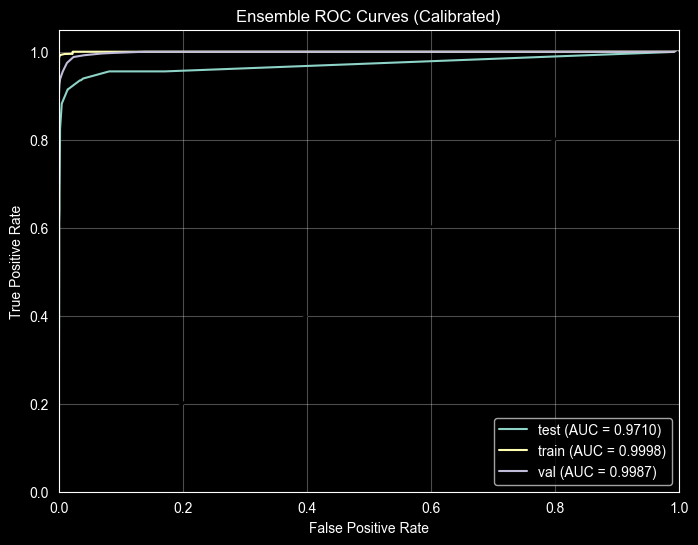

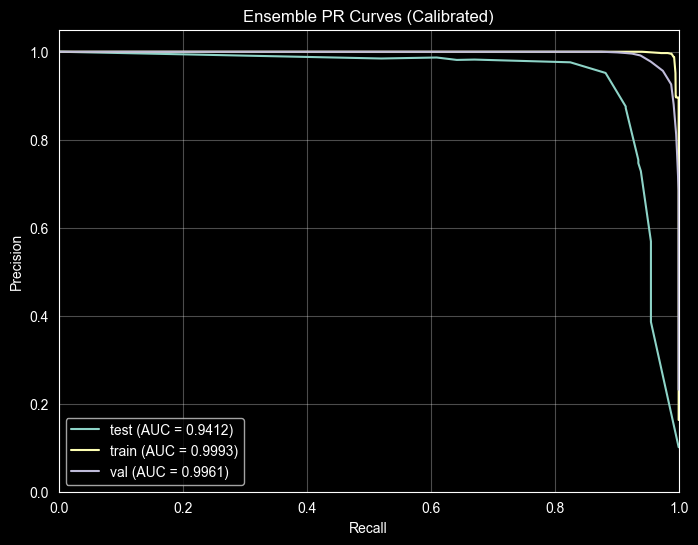

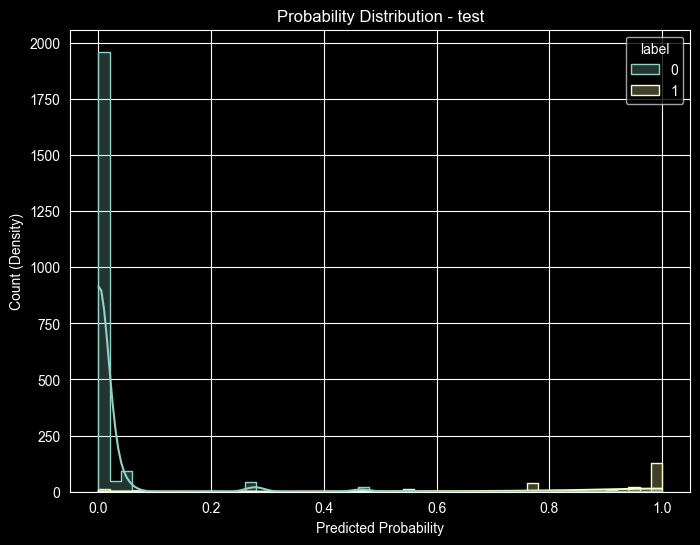

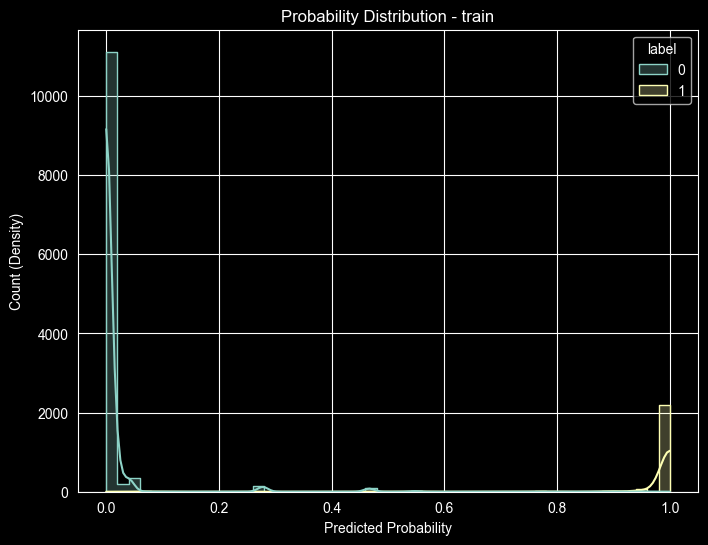

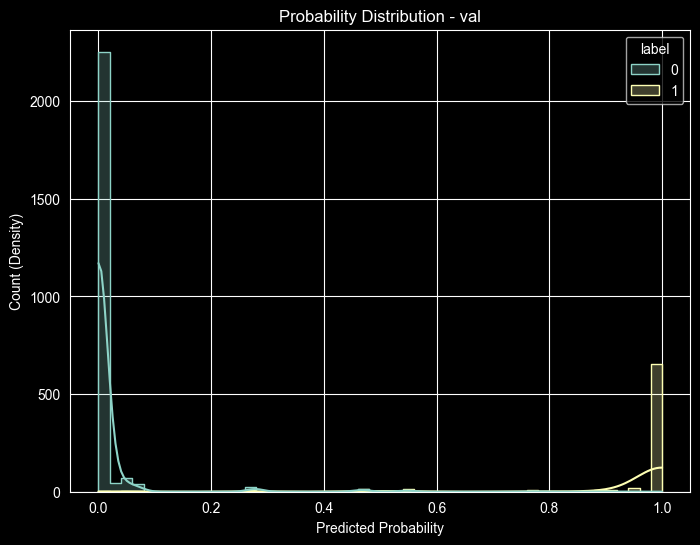


--- Confusion Matrices at Policy Thresholds (Global) ---


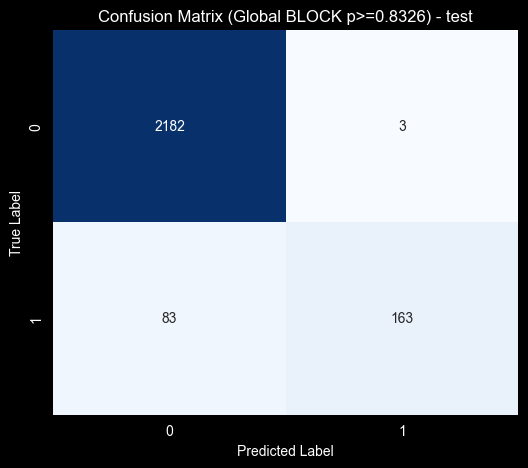

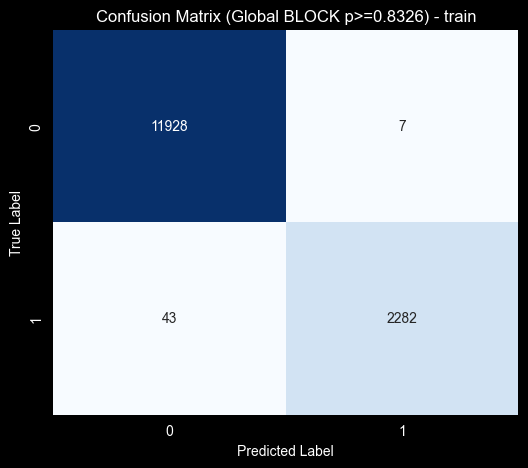

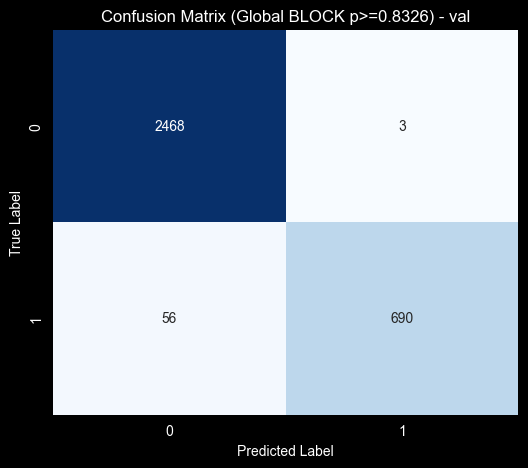

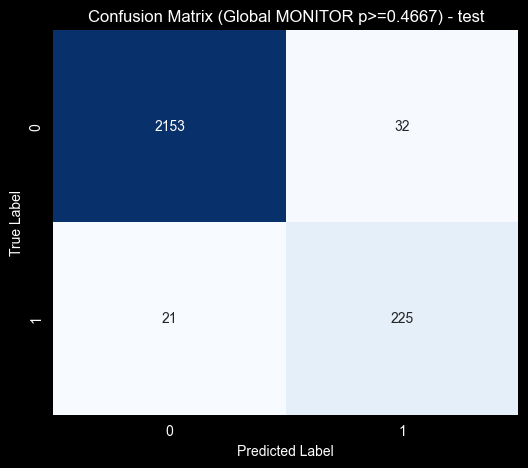

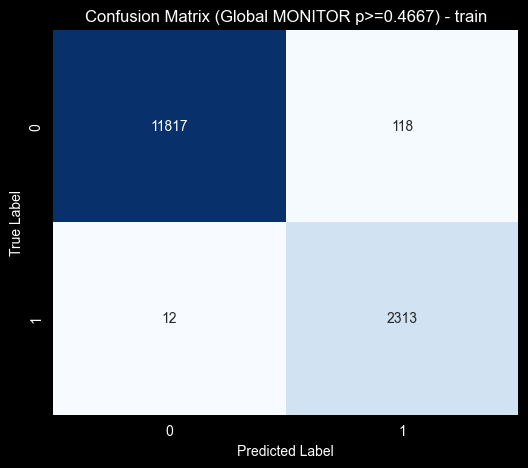

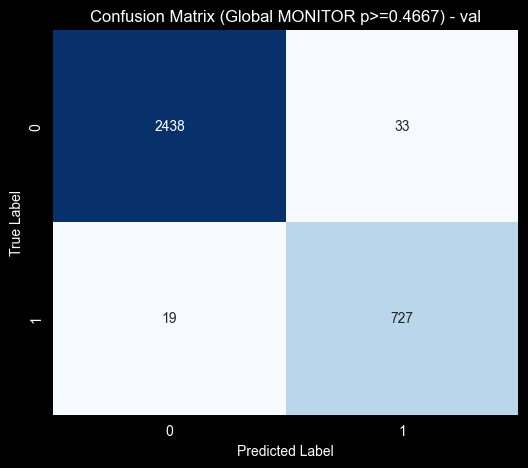

In [6]:
print("\n--- Generating Plots for Ensemble ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")

# NEW: Confusion Matrices for BLOCK and MONITOR thresholds (Global)
print("\n--- Confusion Matrices at Policy Thresholds (Global) ---")
T_BLOCK_GLOBAL = get_thr("global", key_block)
T_MONITOR_GLOBAL = get_thr("global", key_monitor)

plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_BLOCK_GLOBAL, title=f"Confusion Matrix (Global BLOCK p>={T_BLOCK_GLOBAL:.4f})")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_MONITOR_GLOBAL, title=f"Confusion Matrix (Global MONITOR p>={T_MONITOR_GLOBAL:.4f})")

In [7]:
# 6. Dataset Distribution Check
print("\n--- Dataset Distribution Across Splits ---")
dist_table = df_all.groupby(["dataset", "split"]).size().unstack(fill_value=0)
print(dist_table)
pct_table = dist_table.div(dist_table.sum(axis=1), axis=0) * 100
print("\n--- Percentage Distribution ---")
print(pct_table.round(2))
if (dist_table == 0).any().any(): print("\nWARNING: Some splits are empty for a dataset!")
else: print("\nCONFIRMED: Both datasets are present in all splits")



--- Dataset Distribution Across Splits ---
split    test  train   val
dataset                   
iscx     1630   8446  1725
vnat      801   5814  1492

--- Percentage Distribution ---
split     test  train    val
dataset                     
iscx     13.81  71.57  14.62
vnat      9.88  71.72  18.40

CONFIRMED: Both datasets are present in all splits
